In [4]:
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import final as f

In [2]:
df = pd.read_parquet('datasets/prepared_complex.parquet')

In [ ]:
df.groupby('destination_ip')

In [8]:
import pandas as pd
import networkx as nx
import joblib

# 1. Load your complex dataset
# Assuming columns: 'source', 'target', 'weight', 'attack_name'
# df = pd.read_parquet('ml_complex_dataset.parquet')

# 2. Filter for an "Interesting" slice
# Let's grab a mix of Benign and a specific stealthy attack (e.g., Worms)
# This creates a "Narrative" visual
worm_nodes = df[df['attack'] == 'worms']['source_ip'].unique()
visual_df = df[df['source_ip'].isin(worm_nodes) | df['destination_ip'].isin(worm_nodes)].head(500)

# 3. Create the NetworkX object
G = nx.from_pandas_edgelist(visual_df, 'source_ip', 'destination_ip', edge_attr=True, create_using=nx.DiGraph())

# 4. Ensure connectivity for the visual
# We take the largest weakly connected component so the graph isn't fragmented
largest_component = max(nx.weakly_connected_components(G), key=len)
G_sub = G.subgraph(largest_component)

# 5. Save this specific slice for your 10-minute presentation
# This saves both the Graph object and the dataframe slice
# joblib.dump(G_sub, 'presentation_subgraph.graphml')
# visual_df.to_csv('visualization_sample.csv', index=False)

print(f"Sub-graph created with {G_sub.number_of_nodes()} nodes and {G_sub.number_of_edges()} edges.")

Sub-graph created with 15 nodes and 66 edges.


In [9]:
visual_df

,source_ip,destination_ip,edge_weight,is_star_graph,is_chain_graph,is_bridge_link,attack,graph_id,baseline_edge_weight_ratio,baseline_edge_weight_zscore,eigen_1,eigen_2,v1_src,v2_src,src_pagerank,dst_pagerank,global_convergence_steps,node_convergence_steps,spectral_gap,target
939,10.40.85.1,175.45.176.2,-1.411331,0,1,1,benign,1,-0.488966,-0.023992,-26.459229,-26.460802,-0.046745,-0.046226,0.077512,0.782412,17.088098,-0.046111,-21.216552,2
26891,149.171.126.10,175.45.176.0,2.925960,0,1,0,benign,1,7.769474,0.560672,-26.459229,-26.460802,11.491639,11.525606,0.400028,0.756343,17.088098,16.935922,-21.216552,2
26892,149.171.126.10,175.45.176.2,-0.536597,0,1,0,benign,1,-0.451771,-0.023698,-26.459229,-26.460802,11.491639,11.525606,0.400028,0.782412,17.088098,16.935922,-21.216552,2
26893,149.171.126.10,175.45.176.3,1.279272,0,1,0,benign,1,1.053961,-0.006979,-26.459229,-26.460802,11.491639,11.525606,0.400028,0.955934,17.088098,16.935922,-21.216552,2
26894,149.171.126.11,175.45.176.1,-1.478378,0,1,0,benign,1,-0.489874,-0.023999,-26.459229,-26.460802,29.747336,29.834226,0.313816,1.000000,17.088098,16.935922,-21.216552,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129063,175.45.176.3,149.171.126.19,2.765538,0,1,0,exploits,1,6.982358,0.390356,-26.459229,-26.460802,32.738184,32.833744,0.955934,0.290068,17.088098,16.935922,-21.216552,7
129064,175.45.176.3,149.171.126.19,1.615119,0,1,0,fuzzers,1,2.026204,0.011042,-26.459229,-26.460802,32.738184,32.833744,0.955934,0.290068,17.088098,16.935922,-21.216552,8
129065,175.45.176.3,149.171.126.19,2.161162,0,1,0,generic,1,4.160427,0.089221,-26.459229,-26.460802,32.738184,32.833744,0.955934,0.290068,17.088098,16.935922,-21.216552,9
129066,175.45.176.3,149.171.126.19,0.853888,0,1,0,reconnaissance,1,0.250969,-0.017196,-26.459229,-26.460802,32.738184,32.833744,0.955934,0.290068,17.088098,16.935922,-21.216552,15


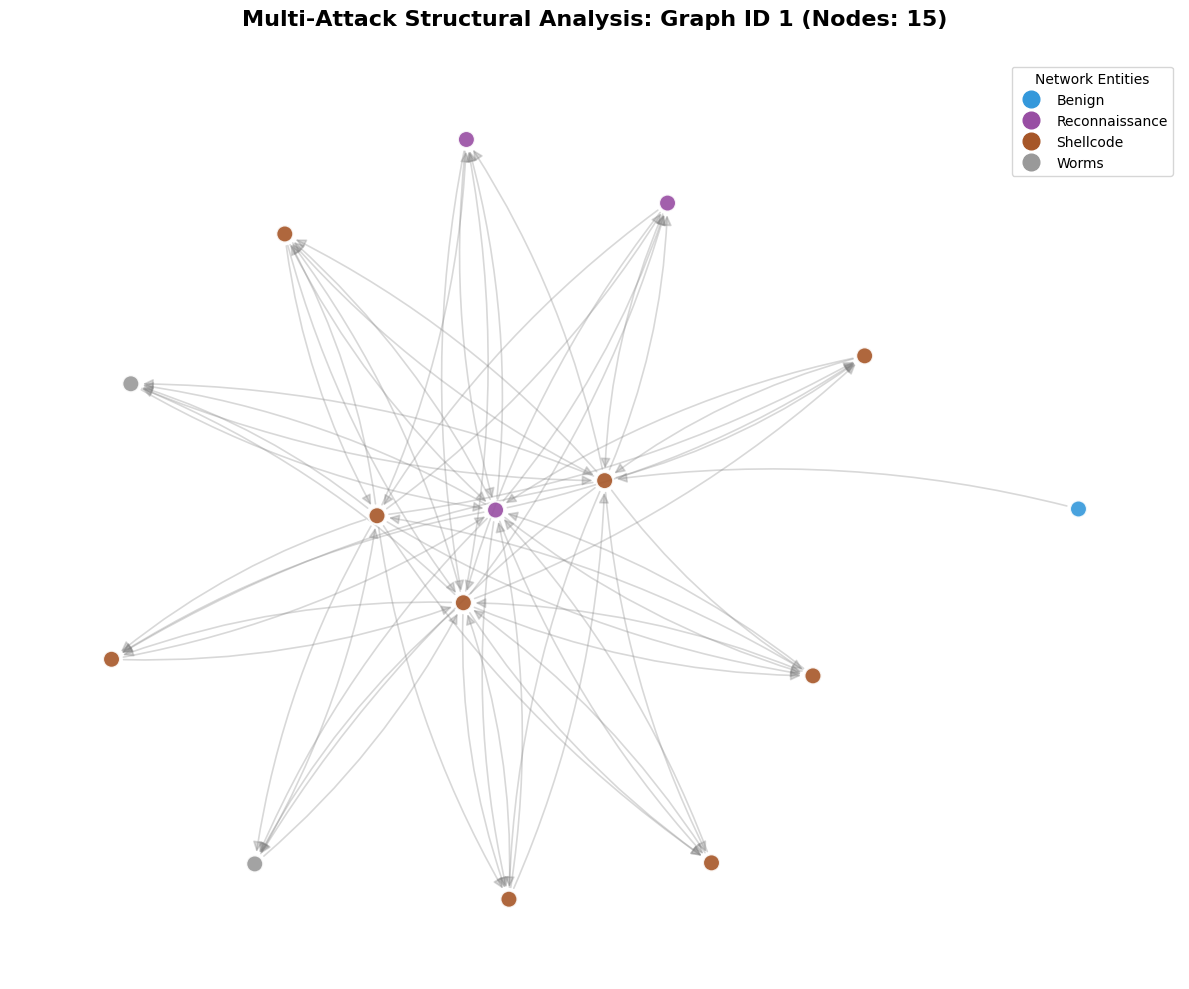

In [16]:
f.plot_complex_graph_multiclass(visual_df, 1)

In [23]:
df['attack'].value_counts()

attack
benign            239310
scanning             737
infilteration        601
dos                  119
ddos                 102
password              73
reconnaissance        72
injection             59
exploits              40
fuzzers               40
generic               40
xss                   39
shellcode             30
backdoor              25
mitm                  24
analysis              16
bot                   10
worms                  8
brute_force            6
theft                  6
ransomware             4
Name: count, dtype: int64

In [25]:
import pandas as pd
import networkx as nx

# 1. Filter for the specific graph component
df_graph1 = df[df['graph_id'] == 1].copy()

# 2. Define the 'Narrative Classes'
rare_stealthy = ['worms', 'ransomware']
obvious = ['ddos']
target_classes = rare_stealthy + obvious + ['benign']

# 3. Targeted Sampling: Get all instances of rare attacks first
rare_df = df_graph1[df_graph1['attack'].isin(rare_stealthy)]
obvious_df = df_graph1[df_graph1['attack'].isin(obvious)]

# 4. Fill with Benign to provide context (e.g., grab 100 benign rows)
# We use a smaller amount of Benign so they don't drown out the visual
benign_df = df_graph1[df_graph1['attack'] == 'benign'].sample(n=min(50, len(df_graph1)), random_state=42)

# 5. Combine and Create Graph
final_viz_df = pd.concat([rare_df, obvious_df, benign_df])

# Save for predictions/reuse
#final_viz_df.to_csv('graph1_comparative_slice.csv', index=False)

print(f"Slice created with:")
print(final_viz_df['attack'].value_counts())

Slice created with:
attack
benign    50
worms      8
Name: count, dtype: int64


In [27]:
# Create a temporary graph of the WHOLE graph_id 1 to find connections
G_full = nx.from_pandas_edgelist(df_graph1, 'source_ip', 'destination_ip')

# Start with your rare attack nodes
rare_nodes = set(rare_df['source_ip']).union(set(rare_df['destination_ip']))

# Find their immediate neighbors to ensure they are connected to 'something'
neighbors = set()
for node in rare_nodes:
    if G_full.has_node(node):
        neighbors.update(G_full.neighbors(node))

# Combine rare nodes + their actual neighbors
connected_nodes = rare_nodes.union(neighbors)

# Now filter the dataframe to only include rows where BOTH ends are in this set
connected_viz_df = df_graph1[
    df_graph1['source_ip'].isin(connected_nodes) & 
    df_graph1['destination_ip'].isin(connected_nodes)
]

In [ ]:
G_test = nx.from_pandas_edgelist(final_viz_df, 'source_ip', 'destination_ip')
is_connected = nx.is_connected(G_test.to_undirected())
num_components = nx.number_connected_components(G_test.to_undirected())

print(f"Is the graph connected? {is_connected}")
print(f"Number of disconnected islands: {num_components}")

Is the graph connected? False
Number of disconnected islands: 3


In [55]:
def generate_graph_ids(pdDataFrame: pd.DataFrame) -> pd.DataFrame:
    # Build the undirected graph
    # Using IPs to ensure we find all 'islands' of communication
    G_temp = nx.from_pandas_edgelist(pdDataFrame, 'source_ip', 'destination_ip')
    
    # Get connected components
    components = list(nx.connected_components(G_temp))
    
    # Map nodes to IDs
    node_to_gid = {node: gid for gid, nodes in enumerate(components) for node in nodes}
    
    # The Fix: Map the row based on the Source IP 
    # (Since they are connected, Source and Dest will map to the same GID anyway)
    pdDataFrame['graph_id'] = pdDataFrame['source_ip'].map(node_to_gid)
    
    # Optional: Fill any NaNs if a Source IP somehow wasn't in the graph
    pdDataFrame['graph_id'] = pdDataFrame['graph_id'].fillna(-1).astype(int)
    
    return pdDataFrame

In [50]:
import pandas as pd
import networkx as nx

def verify_all_graphs(df):
    report = []
    
    for gid in df['graph_id'].unique():
        # Filter for just this graph's data
        sub_df = df[df['graph_id'] == gid]
        
        # Build the graph for this ID
        G = nx.from_pandas_edgelist(sub_df, 'source_ip', 'destination_ip')
        
        # Check connectivity
        is_conn = nx.is_connected(G)
        num_components = nx.number_connected_components(G)
        
        report.append({
            'graph_id': gid,
            'is_connected': is_conn,
            'fragment_count': num_components,
            'edge_count': len(sub_df)
        })
    
    return pd.DataFrame(report)

# Run the verification
verification_df = verify_all_graphs(temp_df)

# Check if any graphs failed the connectivity test
failed_graphs = verification_df[verification_df['is_connected'] == False]
print(f"Total Graphs: {len(verification_df)}")
print(f"Disconnected Graphs found: {len(failed_graphs)}")

KeyError: 'source_ip'

In [64]:
import modeling as m

2026-03-14 17:35:52.480851: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [164]:
df = pd.read_parquet('datasets/prepared_complex.parquet')
stuff = m.prepare_data_for_training(df)

In [68]:
temp = stuff['y_test']

In [70]:
temp.value_counts()

target
2     23692
16       73
10       60
6        12
5        10
15        7
13        7
11        6
9         4
7         4
8         4
20        4
17        3
0         2
12        2
1         2
18        1
14        1
3         1
19        1
4         1
Name: count, dtype: int64

In [78]:
X_test = stuff['X_test']

In [79]:
y_test = stuff['y_test']

In [80]:
verify_all_graphs(temp)

,graph_id,is_connected,fragment_count,edge_count
0,0,False,3,23837
1,1,True,1,33
2,2,True,1,27


In [81]:
import pandas as pd

# Join X_test and y_test into one dataframe
# We use axis=1 to stack them side-by-side
joined_test = pd.concat([X_test, y_test], axis=1)

# Verify the join
print(f"Original X_test shape: {X_test.shape}")
print(f"Joined dataframe shape: {joined_test.shape}")
print(joined_test.head())

Original X_test shape: (23897, 18)
Joined dataframe shape: (23897, 19)
             source_ip  destination_ip  edge_weight  is_star_graph  \
161727  194.187.248.85    172.31.64.77     0.239045              0   
131143    177.52.68.55    172.31.67.34    -0.358077              0   
27396   151.236.38.168    172.31.64.13     0.239601              0   
106385    172.31.67.35  54.172.144.158     1.005378              0   
136170   181.214.87.12    172.31.64.79    -1.495323              0   

        is_chain_graph  is_bridge_link  graph_id  baseline_edge_weight_ratio  \
161727               1               0         0                   -0.272092   
131143               1               0         0                   -0.431515   
27396                1               0         0                   -0.271837   
106385               1               0         0                    0.485153   
136170               1               0         0                   -0.490083   

        baseline_edge_weigh

In [89]:
joined_test['target'].value_counts()

target
2     23692
16       73
10       60
6        12
5        10
15        7
13        7
11        6
9         4
7         4
8         4
20        4
17        3
0         2
12        2
1         2
18        1
14        1
3         1
19        1
4         1
Name: count, dtype: int64

In [132]:
joined_test.to_parquet('datasets/comparison_data.parquet')

In [176]:
import pandas as pd
import networkx as nx

def get_reconstructed(joined_test):
    # 1. Build the full graph for the component (e.g., Graph ID 0)
    # We use the full 'temp' df to ensure we have all possible bridges
    G_full = nx.from_pandas_edgelist(joined_test[joined_test['graph_id'] == 0], 'source_ip', 'destination_ip')

    # 2. Identify 'Patient Zero' (All Worm nodes)
    # Change 'target' or 'attack' to match your label column name
    worm_rows = joined_test[joined_test['target'] == 18] # Based on your value_counts, 18 is worms
    worm_nodes = set(worm_rows['source_ip']).union(set(worm_rows['destination_ip']))

    # 3. Step Out (Neighborhood Expansion)
    # We use k=2 to see the immediate 'blast radius'
    nodes_to_include = set(worm_nodes)
    for _ in range(5): # Number of steps to 'step out'
        new_neighbors = set()
        for node in nodes_to_include:
            if G_full.has_node(node):
                new_neighbors.update(G_full.neighbors(node))
        nodes_to_include.update(new_neighbors)

    # 4. Filter the original dataframe for these specific nodes
    # This ensures we get all edges connecting this specific cluster
    reconstructed_df = joined_test[
        (joined_test['source_ip'].isin(nodes_to_include)) & 
        (joined_test['destination_ip'].isin(nodes_to_include))
    ]

    # 5. Verification
    G_reconstructed = nx.from_pandas_edgelist(reconstructed_df, 'source_ip', 'destination_ip')
    print(f"Nodes in reconstruction: {len(G_reconstructed.nodes())}")
    print(f"Is it connected? {nx.is_connected(G_reconstructed)}")
    return G_reconstructed, reconstructed_df

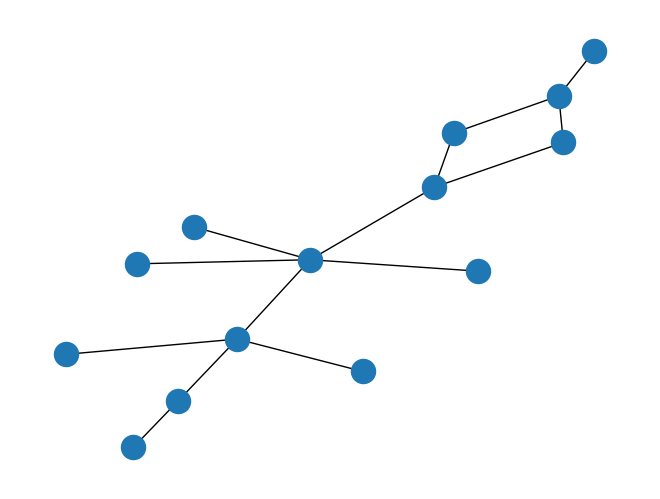

In [ ]:
G_reconstructed = get_reconstructed(joined_test)
nx.draw(G_reconstructed)

In [ ]:
def map_target_name(reconstructed_df):
    # The original dictionary you provided
    ATTACK_MAPPING = {
        'scanning': 16, 'benign': 2, 'ddos': 5, 'dos': 6, 'xss': 20,
        'reconnaissance': 15, 'password': 13, 'injection': 11,
        'brute_force': 4, 'fuzzers': 8, 'bot': 3, 'infilteration': 10,
        'generic': 9, 'backdoor': 1, 'exploits': 7, 'ransomware': 14,
        'mitm': 12, 'theft': 18, 'shellcode': 17, 'analysis': 0, 'worms': 19
    }

    # Step 1: Invert it (Numbers become keys)
    id_to_name = {v: k for k, v in ATTACK_MAPPING.items()}

    # Step 2: Map it to the joined_test dataframe
    # Replace 'target' with the actual column name of your numerical labels
    reconstructed_df['attack_name'] = reconstructed_df['target'].map(id_to_name)

    # Verification
    print(reconstructed_df[['target', 'attack_name']].head())
    return reconstructed_df

        target     attack_name
159781      15  reconnaissance
159857      18           theft
159777       2          benign
159820       6             dos
159757       2          benign


In [ ]:
map_target_name(reconstructed_df)
reconstructed_df

,source_ip,destination_ip,edge_weight,is_star_graph,is_chain_graph,is_bridge_link,graph_id,baseline_edge_weight_ratio,baseline_edge_weight_zscore,eigen_1,eigen_2,v1_src,v2_src,src_pagerank,dst_pagerank,global_convergence_steps,node_convergence_steps,spectral_gap,target,attack_name
159781,192.168.100.148,192.168.100.3,3.776413,0,1,0,0,12.038058,3.603651,0.039844,0.039826,2.599199,1.858952,0.000004,1.700976e-03,-0.002568,8.977029,0.047133,15,reconnaissance
159857,192.168.100.3,192.168.100.149,1.648747,0,1,0,0,2.139673,0.013668,0.039844,0.039826,9.520126,8.531217,0.001701,4.085937e-06,-0.002568,9.218831,0.047133,18,theft
159777,192.168.100.148,144.48.166.166,-1.198988,0,1,0,0,-0.485060,-0.023961,0.039844,0.039826,2.599199,1.858952,0.000004,2.054984e-07,-0.002568,8.977029,0.047133,2,benign
159820,192.168.100.150,192.168.100.3,4.050224,0,1,0,0,13.426931,6.504898,0.039844,0.039826,2.562180,0.670667,0.000008,1.700976e-03,-0.002568,8.795960,0.047133,6,dos
159757,192.168.100.147,129.250.35.251,-1.198988,0,1,0,0,-0.485060,-0.023961,0.039844,0.039826,2.502053,1.820877,0.000004,5.770060e-08,-0.002568,8.973774,0.047133,2,benign
159918,192.168.100.5,192.168.100.148,0.088709,0,1,0,0,-0.331694,-0.022719,0.039844,0.039826,44.548458,44.812363,0.000191,4.116584e-06,-0.002568,9.445578,0.047133,15,reconnaissance
159767,192.168.100.147,192.168.100.6,3.777406,0,1,0,0,12.043090,3.611393,0.039844,0.039826,2.502053,1.820877,0.000004,1.931997e-05,-0.002568,8.973774,0.047133,6,dos
159910,192.168.100.46,192.168.100.5,5.843589,0,1,0,0,22.552092,306.448985,0.039844,0.039826,43.594756,44.016992,0.000094,1.910661e-04,-0.002568,9.443210,0.047133,2,benign
159894,192.168.100.3,205.251.198.106,-0.691175,0,1,1,0,-0.464104,-0.023796,0.039844,0.039826,9.520126,8.531217,0.001701,2.527625e-09,-0.002568,9.218831,0.047133,2,benign
159853,192.168.100.3,192.168.100.149,2.243133,0,1,0,0,4.523420,0.111007,0.039844,0.039826,9.520126,8.531217,0.001701,4.085937e-06,-0.002568,9.218831,0.047133,2,benign


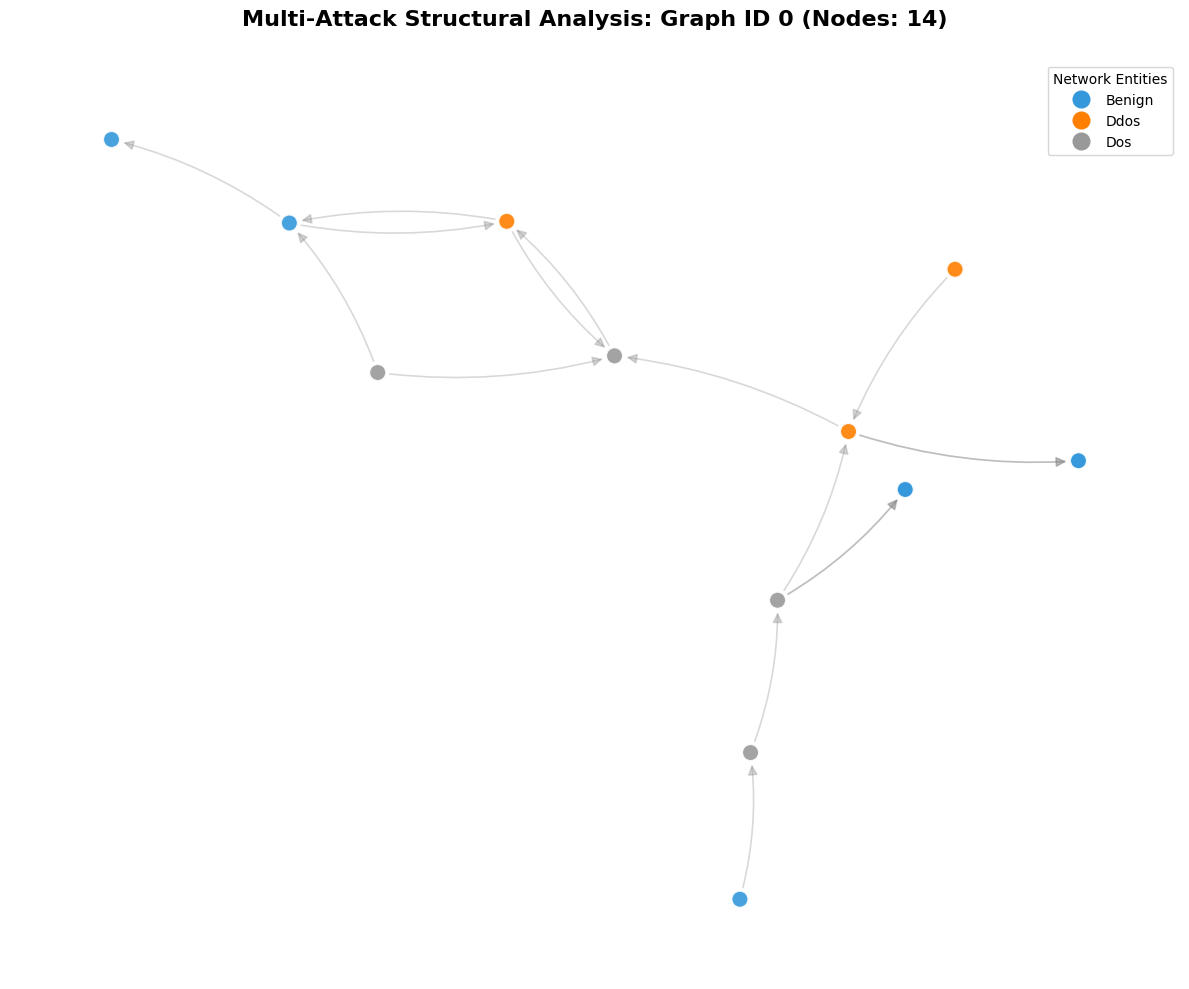

In [129]:
f.plot_complex_graph_multiclass(reconstructed_df, 0)

--- Narrative Visualization Debug ---
Unique targets in Dataframe: [2, 5, 6, 15, 18]
Nodes in Graph: 14
Color counts assigned: {'#3498db': 6, '#c0392b': 4, '#9b59b6': 3, '#f1c40f': 1}


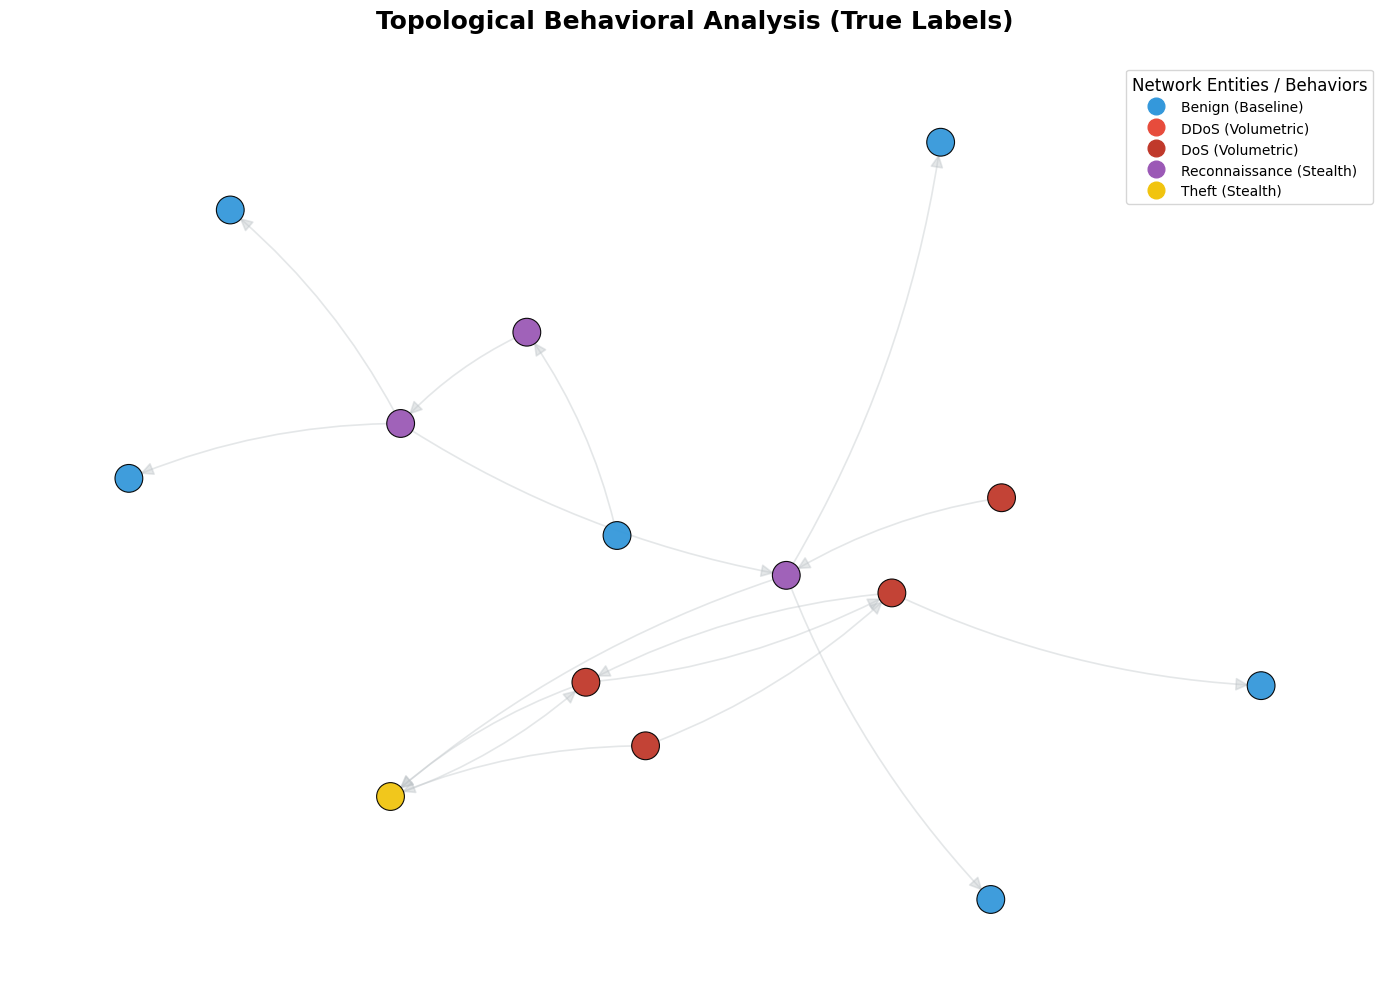

In [151]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.lines as mlines
import pandas as pd

def plot_final_narrative_graph(df_slice, node_size=400):
    '''
    Plots a multi-class network graph with priority-based coloring 
    to ensure stealthy attacks are visible over benign noise.
    '''
    
    # 1. Build the Priority Map
    # Lower value = Higher visual priority. 
    # We want stealthy attacks (15, 18) to override everything.
    priority_map = {
        15: 1, # Reconnaissance (High Priority)
        18: 1, # Theft (High Priority)
        5:  2, # DDoS
        6:  2, # DoS
        2:  3  # Benign (Lowest Priority)
    }

    # 2. Build the Identity Map (The "Malice Priority" logic)
    node_identity = {}
    for _, row in df_slice.iterrows():
        for ip in [row['source_ip'], row['destination_ip']]:
            new_target = row['target']
            current_target = node_identity.get(ip, 99) # 99 is default low priority
            
            # Update node identity only if the new target has higher priority (lower number)
            if priority_map.get(new_target, 10) < priority_map.get(current_target, 10):
                node_identity[ip] = new_target

    # 3. Create the Directed Graph
    G = nx.from_pandas_edgelist(df_slice, 'source_ip', 'destination_ip', create_using=nx.DiGraph())

    # 4. Define the Narrative Palette
    color_palette = {
        2:  '#3498db', # Benign (Blue)
        5:  '#e74c3c', # DDoS (Red)
        6:  '#c0392b', # DoS (Dark Red)
        15: '#9b59b6', # Reconnaissance (Purple)
        18: '#f1c40f'  # Theft (Yellow)
    }

    # 5. Assign Colors to Nodes in the Graph
    node_colors = []
    for node in G.nodes():
        t_id = node_identity.get(node)
        # Use the palette, fallback to gray if the ID is unexpected
        color = color_palette.get(t_id, '#95a5a6')
        node_colors.append(color)

    # --- Debug Verification ---
    print("--- Narrative Visualization Debug ---")
    print(f"Unique targets in Dataframe: {sorted(df_slice['target'].unique())}")
    print(f"Nodes in Graph: {len(G.nodes())}")
    color_counts = pd.Series(node_colors).value_counts().to_dict()
    print(f"Color counts assigned: {color_counts}")

    # 6. Plotting Configuration
    plt.figure(figsize=(14, 10))
    # spring_layout with k=0.6 spreads nodes out so colors aren't hidden
    pos = nx.spring_layout(G, k=0.6, iterations=50, seed=42)
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors, 
                           edgecolors='black', linewidths=0.8, alpha=0.95)
    
    # Draw Edges (curved lines help see bi-directional traffic)
    nx.draw_networkx_edges(G, pos, edge_color='#bdc3c7', alpha=0.4, 
                           width=1.2, arrows=True, arrowsize=20, 
                           connectionstyle='arc3,rad=0.1')

    # 7. Create Static Legend (Always shows all 5 for presentation consistency)
    legend_targets = [
        ('Benign (Baseline)', 2), 
        ('DDoS (Volumetric)', 5), 
        ('DoS (Volumetric)', 6), 
        ('Reconnaissance (Stealth)', 15), 
        ('Theft (Stealth)', 18)
    ]
    
    handles = [mlines.Line2D([], [], color=color_palette[t[1]], marker='o', 
                             linestyle='None', markersize=12, label=t[0]) 
               for t in legend_targets]
    
    plt.legend(handles=handles, title="Network Entities / Behaviors", 
               loc='upper right', frameon=True, fontsize=10, title_fontsize=12)
    
    plt.title(f"Topological Behavioral Analysis (True Labels)", 
              fontsize=18, fontweight='bold', pad=25)
    
    plt.axis('off')
    plt.tight_layout()
    
    # Optional: Save for slides
    # plt.savefig('topology_comparison.png', dpi=300, bbox_inches='tight')
    
    plt.show()

# To use: 
plot_final_narrative_graph(reconstructed_df)

In [ ]:
# 1. Calculate the layout ONCE using the full graph structure
G_main = nx.from_pandas_edgelist(reconstructed_df, 'source_ip', 'destination_ip')
# Use a high iteration count for stability
fixed_pos = nx.spring_layout(G_main, k=1.0, iterations=100, seed=42)

# 2. Update your function to accept 'pos' as a parameter
def plot_final_narrative_graph(df_slice, pos, title_suffix="(True Labels)", node_size=400):
    # ... [Keep your Priority and Identity mapping logic] ...
    
    G = nx.from_pandas_edgelist(df_slice, 'source_ip', 'destination_ip', create_using=nx.DiGraph())
    
    # [Mapping colors code...]

    plt.figure(figsize=(14, 10))
    
    # Use the FIXED position passed into the function
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors, ...)
    nx.draw_networkx_edges(G, pos, ...)
    
    # Draw large labels using the same fixed pos with an offset
    label_pos = {k: [v[0], v[1] + 0.07] for k, v in pos.items()}
    nx.draw_networkx_labels(G, label_pos, font_size=12, font_weight='bold')

    plt.title(f"Topological Behavioral Analysis {title_suffix}", fontsize=18, fontweight='bold')
    plt.show()

# 3. Use it for your comparison slides
plot_final_narrative_graph(reconstructed_df, fixed_pos, title_suffix="(True Labels)")
# Then run it again with your prediction-based colors using the SAME fixed_pos
plot_final_narrative_graph(reconstructed_df, fixed_pos, title_suffix="(Model Predictions)")

SyntaxError: positional argument follows keyword argument (1521897478.py, line 17)

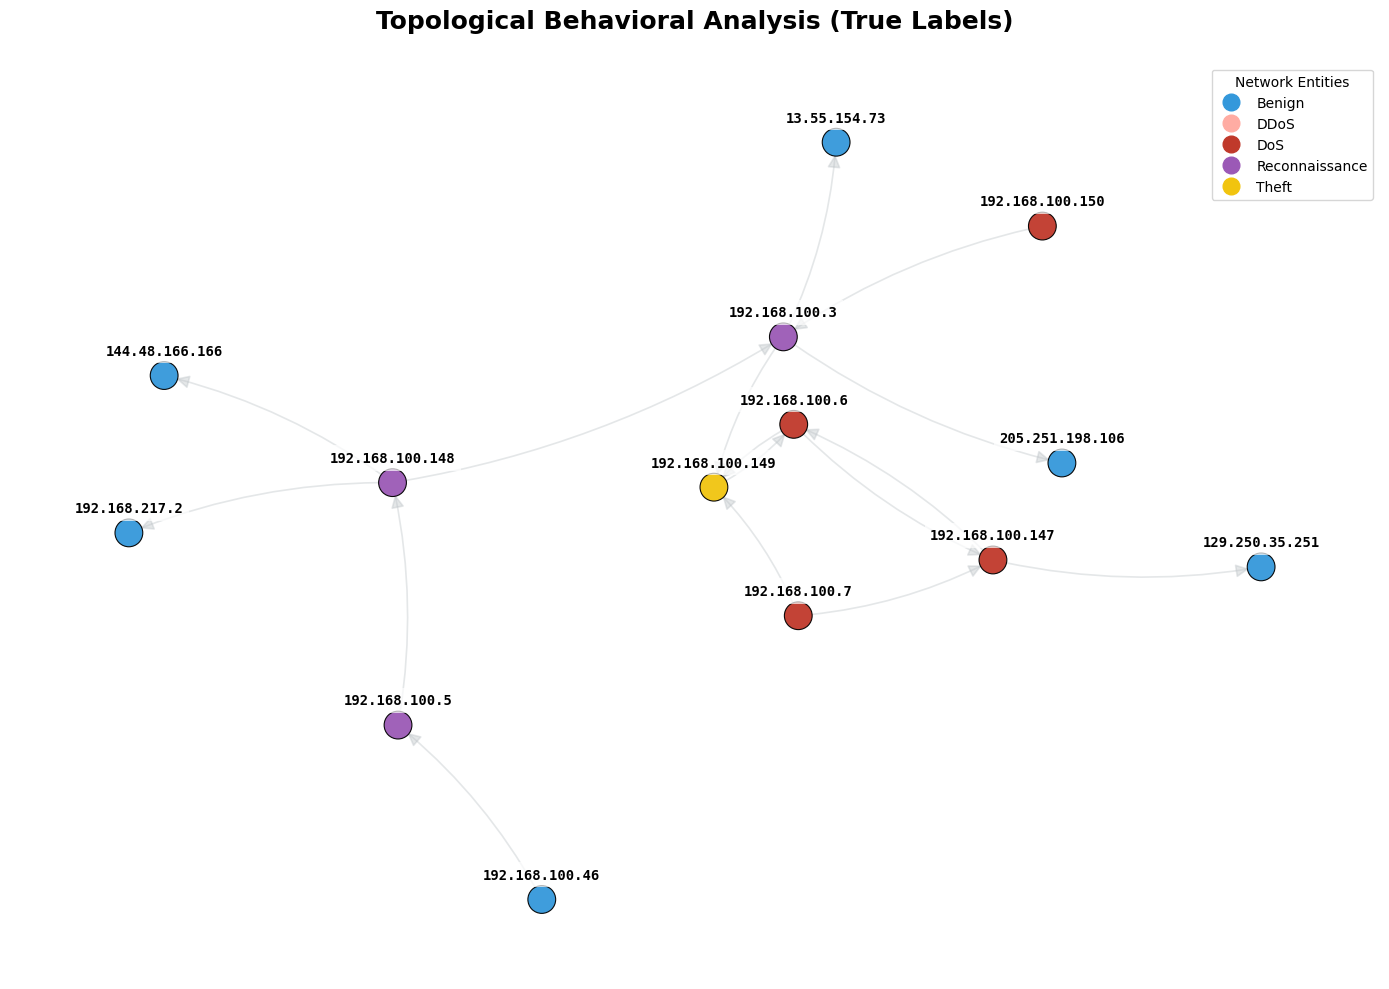

In [156]:
# 1. Calculate the layout ONCE using the full graph structure
G_main = nx.from_pandas_edgelist(reconstructed_df, 'source_ip', 'destination_ip')
# Use a high iteration count for stability
fixed_pos = nx.spring_layout(G_main, k=1.0, iterations=100, seed=42)
def plot_final_narrative_graph(df_slice, pos, title_suffix="(True Labels)", node_size=400):
    # 1. Build Priority Map
    priority_map = {15: 1, 18: 1, 5: 2, 6: 2, 2: 3}

    # 2. Build Identity Map
    node_identity = {}
    for _, row in df_slice.iterrows():
        for ip in [row['source_ip'], row['destination_ip']]:
            new_target = row['target']
            current_target = node_identity.get(ip, 99)
            if priority_map.get(new_target, 10) < priority_map.get(current_target, 10):
                node_identity[ip] = new_target

    # 3. Create Graph
    G = nx.from_pandas_edgelist(df_slice, 'source_ip', 'destination_ip', create_using=nx.DiGraph())

    # 4. Assign Colors
    color_palette = {2: '#3498db', 5: "#ffaca3", 6: '#c0392b', 15: '#9b59b6', 18: '#f1c40f'}
    node_colors = [color_palette.get(node_identity.get(node), '#95a5a6') for node in G.nodes()]

    # 5. Plotting (Using the fixed 'pos')
    plt.figure(figsize=(14, 10))
    
    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors, 
                           edgecolors='black', linewidths=0.8, alpha=0.95)
    
    nx.draw_networkx_edges(G, pos, edge_color='#bdc3c7', alpha=0.4, 
                           width=1.2, arrows=True, arrowsize=20, 
                           connectionstyle='arc3,rad=0.1')

    # 6. Large Labels (Linked to fixed 'pos')
    label_pos = {k: [v[0], v[1] + 0.06] for k, v in pos.items()} 
    nx.draw_networkx_labels(G, label_pos, font_size=10, font_family='monospace', 
                            font_weight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    # 7. Legend
    legend_targets = [('Benign', 2), ('DDoS', 5), ('DoS', 6), ('Reconnaissance', 15), ('Theft', 18)]
    handles = [mlines.Line2D([], [], color=color_palette[t[1]], marker='o', 
                             linestyle='None', markersize=12, label=t[0]) for t in legend_targets]
    
    plt.legend(handles=handles, title="Network Entities", loc='upper right', frameon=True)
    plt.title(f"Topological Behavioral Analysis {title_suffix}", fontsize=18, fontweight='bold', pad=25)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# 3. Use it for your comparison slides
plot_final_narrative_graph(reconstructed_df, fixed_pos, title_suffix="(True Labels)")
# Then run it again with your prediction-based colors using the SAME fixed_pos
#plot_final_narrative_graph(reconstructed_df, fixed_pos, title_suffix="(Model Predictions)")

In [158]:
X_test

,source_ip,destination_ip,edge_weight,is_star_graph,is_chain_graph,is_bridge_link,graph_id,baseline_edge_weight_ratio,baseline_edge_weight_zscore,eigen_1,eigen_2,v1_src,v2_src,src_pagerank,dst_pagerank,global_convergence_steps,node_convergence_steps,spectral_gap
161727,194.187.248.85,172.31.64.77,0.239045,0,1,0,0,-0.272092,-0.022214,0.039844,0.039826,-0.046817,-0.046299,0.000000,0.005807,-0.002568,0.222820,0.047133
131143,177.52.68.55,172.31.67.34,-0.358077,0,1,0,0,-0.431515,-0.023536,0.039844,0.039826,-0.046817,-0.046299,0.000000,0.004908,-0.002568,-0.375257,0.047133
27396,151.236.38.168,172.31.64.13,0.239601,0,1,0,0,-0.271837,-0.022212,0.039844,0.039826,-0.046817,-0.046299,0.000000,0.003003,-0.002568,-0.375257,0.047133
106385,172.31.67.35,54.172.144.158,1.005378,0,1,0,0,0.485153,-0.014564,0.039844,0.039826,-0.046817,-0.046299,0.004875,0.000035,-0.002568,0.222820,0.047133
136170,181.214.87.12,172.31.64.79,-1.495323,0,1,0,0,-0.490083,-0.024000,0.039844,0.039826,-0.046817,-0.046299,0.000000,0.005788,-0.002568,-0.375257,0.047133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92877,172.31.66.82,54.164.251.13,0.715600,0,1,0,0,0.080474,-0.018954,0.039844,0.039826,-0.046817,-0.046299,0.012603,0.000029,-0.002568,0.222820,0.047133
190516,23.102.209.160,172.31.65.48,-0.358077,0,1,0,0,-0.431515,-0.023536,0.039844,0.039826,-0.046817,-0.046299,0.000000,0.005814,-0.002568,-0.799600,0.047133
87366,172.31.66.61,209.85.202.95,0.605979,0,1,0,0,-0.029274,-0.020022,0.039844,0.039826,-0.046817,-0.046299,0.008235,0.005124,-0.002568,0.222820,0.047133
103526,172.31.67.17,54.230.36.67,0.439689,0,1,0,0,-0.159913,-0.021229,0.039844,0.039826,-0.046817,-0.046299,0.005125,0.002041,-0.002568,0.222820,0.047133


In [187]:
import joblib
import pandas as pd

def compute_pred(df):
    """
    1. Resets index to ensure unique mapping.
    2. Captures IP addresses for graph reconstruction.
    3. Runs the complex model prediction.
    4. Joins features, targets, predictions, and IPs into one DataFrame.
    """
    # --- STEP 0: Force a unique index to prevent "duplicate labels" error ---
    # This is critical if the input DF was concatenated from multiple sources
    df = df.reset_index(drop=True)

    ATTACK_MAPPING = {
        'scanning': 16, 'benign': 2, 'ddos': 5, 'dos': 6, 'xss': 20,
        'reconnaissance': 15, 'password': 13, 'injection': 11,
        'brute_force': 4, 'fuzzers': 8, 'bot': 3, 'infilteration': 10,
        'generic': 9, 'backdoor': 1, 'exploits': 7, 'ransomware': 14,
        'mitm': 12, 'theft': 18, 'shellcode': 17, 'analysis': 0, 'worms': 19
    }
    # Invert to go from ID (number) -> Name (string)
    ID_TO_NAME = {v: k for k, v in ATTACK_MAPPING.items()}

    # --- STEP 1: Capture IPs and Metadata before they are dropped for ML ---
    # We store these so we can rebuild the network graph later
    ip_storage = df[['source_ip', 'destination_ip', 'graph_id']]

    # --- STEP 2: Prepare Data for Training ---
    # This function drops the non-numeric strings to make X_test "ML-ready"
    temp_dict = m.prepare_data_for_training(
        df, 
        cols_to_drop=['source_ip', 'destination_ip', 'attack', 'target']
    )
    X_test = temp_dict['X_test']
    y_test = temp_dict['y_test']

    # --- STEP 3: Load Model & Predict ---
    model_path = 'models/ml_complex_model.joblib'
    complex_model = joblib.load(model_path)
    
    # Ensure we only predict on the columns the model was trained on
    y_pred = complex_model.predict(X_test)

    # --- STEP 4: Reconstruction (The Join) ---
    # Create a series for predictions aligned with the X_test index
    preds_series = pd.Series(y_pred, index=X_test.index, name='prediction')
    
    # Join everything back together using the index as the "glue"
    final_df = pd.concat([
        X_test, 
        y_test.rename('target'), 
        preds_series,
        ip_storage.loc[X_test.index] # Re-attaches source_ip and destination_ip
    ], axis=1)

    # --- STEP 5: Mapping & Success Metrics ---
    final_df['target_name'] = final_df['target'].map(ID_TO_NAME)
    final_df['pred_name'] = final_df['prediction'].map(ID_TO_NAME)
    final_df['is_correct'] = final_df['target'] == final_df['prediction']

    # --- Debug Verification ---
    print(f"Reconstruction Complete.")
    print(f"Rows in final DF: {len(final_df)}")
    print(f"Unique targets found: {final_df['target_name'].unique()}")
    
    return final_df

In [188]:
pred_df = compute_pred(df)

Reconstruction Complete.
Rows in final DF: 23897
Unique targets found: <ArrowStringArray>
[        'benign',            'dos',       'scanning',       'analysis',
        'generic', 'reconnaissance',  'infilteration',          'theft',
           'ddos',     'ransomware',      'injection',       'exploits',
        'fuzzers',            'xss',           'mitm',      'shellcode',
       'password',            'bot',       'backdoor',          'worms',
    'brute_force']
Length: 21, dtype: str


In [189]:
pred_df

,edge_weight,is_star_graph,is_chain_graph,is_bridge_link,graph_id,baseline_edge_weight_ratio,baseline_edge_weight_zscore,eigen_1,eigen_2,v1_src,...,node_convergence_steps,spectral_gap,target,prediction,source_ip,destination_ip,graph_id,target_name,pred_name,is_correct
161727,0.239045,0,1,0,0,-0.272092,-0.022214,0.039844,0.039826,-0.046817,...,0.222820,0.047133,2,2,194.187.248.85,172.31.64.77,0,benign,benign,True
131143,-0.358077,0,1,0,0,-0.431515,-0.023536,0.039844,0.039826,-0.046817,...,-0.375257,0.047133,2,2,177.52.68.55,172.31.67.34,0,benign,benign,True
27396,0.239601,0,1,0,0,-0.271837,-0.022212,0.039844,0.039826,-0.046817,...,-0.375257,0.047133,2,2,151.236.38.168,172.31.64.13,0,benign,benign,True
106385,1.005378,0,1,0,0,0.485153,-0.014564,0.039844,0.039826,-0.046817,...,0.222820,0.047133,2,2,172.31.67.35,54.172.144.158,0,benign,benign,True
136170,-1.495323,0,1,0,0,-0.490083,-0.024000,0.039844,0.039826,-0.046817,...,-0.375257,0.047133,2,2,181.214.87.12,172.31.64.79,0,benign,benign,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92877,0.715600,0,1,0,0,0.080474,-0.018954,0.039844,0.039826,-0.046817,...,0.222820,0.047133,2,2,172.31.66.82,54.164.251.13,0,benign,benign,True
190516,-0.358077,0,1,0,0,-0.431515,-0.023536,0.039844,0.039826,-0.046817,...,-0.799600,0.047133,2,2,23.102.209.160,172.31.65.48,0,benign,benign,True
87366,0.605979,0,1,0,0,-0.029274,-0.020022,0.039844,0.039826,-0.046817,...,0.222820,0.047133,2,2,172.31.66.61,209.85.202.95,0,benign,benign,True
103526,0.439689,0,1,0,0,-0.159913,-0.021229,0.039844,0.039826,-0.046817,...,0.222820,0.047133,2,2,172.31.67.17,54.230.36.67,0,benign,benign,True


In [ ]:
import pandas as pd
import networkx as nx

def get_reconstructed(joined_test):
    # 1. Build the full graph for the component (e.g., Graph ID 0)
    # We use the full 'temp' df to ensure we have all possible bridges
    G_full = nx.from_pandas_edgelist(joined_test[joined_test['graph_id'] == 0], 'source_ip', 'destination_ip')

    # 2. Identify 'Patient Zero' (All Worm nodes)
    # Change 'target' or 'attack' to match your label column name
    worm_rows = joined_test[joined_test['target'] == 18] # Based on your value_counts, 18 is worms
    worm_nodes = set(worm_rows['source_ip']).union(set(worm_rows['destination_ip']))

    # 3. Step Out (Neighborhood Expansion)
    # We use k=2 to see the immediate 'blast radius'
    nodes_to_include = set(worm_nodes)
    for _ in range(5): # Number of steps to 'step out'
        new_neighbors = set()
        for node in nodes_to_include:
            if G_full.has_node(node):
                new_neighbors.update(G_full.neighbors(node))
        nodes_to_include.update(new_neighbors)

    # 4. Filter the original dataframe for these specific nodes
    # This ensures we get all edges connecting this specific cluster
    reconstructed_df = joined_test[
        (joined_test['source_ip'].isin(nodes_to_include)) & 
        (joined_test['destination_ip'].isin(nodes_to_include))
    ]

    # 5. Verification
    G_reconstructed = nx.from_pandas_edgelist(reconstructed_df, 'source_ip', 'destination_ip')
    print(f"Nodes in reconstruction: {len(G_reconstructed.nodes())}")
    print(f"Is it connected? {nx.is_connected(G_reconstructed)}")
    return G_reconstructed, reconstructed_df

In [190]:
get_reconstructed(pred_df)

ValueError: cannot reindex on an axis with duplicate labels

In [191]:
so_many_blurbs = pd.read_parquet('datasets/clean_short.parquet')

In [202]:
cols_to_keep = [
    'ipv4_src_addr',
    'ipv4_dst_addr',
    'in_bytes',
    'out_bytes',
    'attack'
]
so_many_blurbs[so_many_blurbs['in_bytes'] == 44][cols_to_keep]['attack'].value_counts()

attack
benign            241841
reconnaissance     71617
scanning           34769
infilteration       1112
ddos                 148
password              36
dos                   17
Name: count, dtype: int64

In [203]:
# Filter for 44 bytes, then keep the first occurrence of each unique attack
unique_examples = so_many_blurbs[so_many_blurbs['in_bytes'] == 44].drop_duplicates(subset='attack')

# Show your specific columns for these unique examples
unique_examples[cols_to_keep]

,ipv4_src_addr,ipv4_dst_addr,in_bytes,out_bytes,attack
53864551,192.168.1.31,192.168.35.45,44,0,scanning
1117388,192.168.1.34,192.168.1.49,44,0,benign
58230445,192.168.100.149,192.168.100.5,44,40,reconnaissance
27953837,172.31.69.13,172.31.69.7,44,40,infilteration
43132694,192.168.100.3,192.168.100.148,44,180,ddos
39032043,192.168.1.31,192.168.1.195,44,44,password
10984851,192.168.100.7,192.168.100.148,44,180,dos


In [5]:
#base = pd.read_parquet('datasets/raw_full.parquet')
short = pd.read_parquet('datasets/raw_short.parquet')

In [20]:
print(f'\033[35m===== FULL DATASET SHAPE: =====\033[0m')
rowCol = base.shape
print(f'Rows: {rowCol[0]}')
print(f'Cols: {rowCol[1]}')
print()

print(f'\033[35m===== SHORT DATASET SHAPE =====\033[0m')
rowCol = short.shape
print(f'Percent reduction: {(short.shape[0]/base.shape[0])*100:.1f}%')
print(f'Rows: {rowCol[0]}')
print(f'Cols: {rowCol[1]}')
print()

print(f'\033[35m===== TARGET/PREDICTION VARIABLE =====\033[0m')
print('Feature Name: Attack')
print(f'Total Types: {short["Attack"].nunique()}')
print(short['Attack'].unique())

===== FULL DATASET SHAPE: =====
Rows: 75987976
Cols: 46

===== SHORT DATASET SHAPE =====
Percent reduction: 5.0%
Rows: 3799399
Cols: 46

===== TARGET/PREDICTION VARIABLE =====
Feature Name: Attack
Total Types: 21
<ArrowStringArray>
[      'scanning',         'Benign',           'DDoS',            'DoS',
            'xss', 'Reconnaissance',       'password',      'injection',
    'Brute Force',        'Fuzzers',            'Bot',  'Infilteration',
        'Generic',       'Backdoor',       'Exploits',     'ransomware',
           'mitm',          'Theft',      'Shellcode',       'Analysis',
          'Worms']
Length: 21, dtype: str


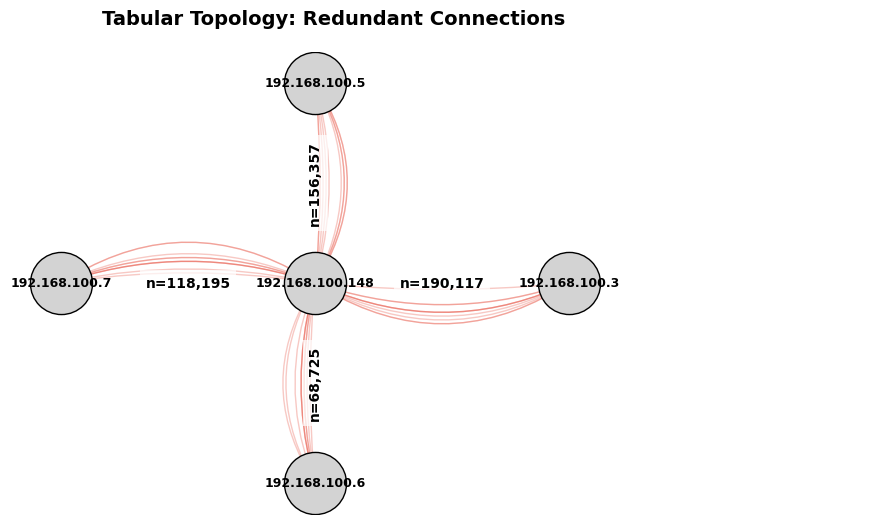

In [56]:
import networkx as nx
import matplotlib.pyplot as plt
import math

def plot_multi_with_counts(df, src_ip, dst_ips, edges_per_pair=10):
    G = nx.MultiDiGraph()
    edge_counts = {} # To store the "Real" count from the data

    for dst in dst_ips:
        pair_df = df[(df['IPV4_SRC_ADDR'] == src_ip) & (df['IPV4_DST_ADDR'] == dst)]
        total_count = len(pair_df)
        edge_counts[(src_ip, dst)] = total_count
        
        # Sample for the visual "clutter"
        sample = pair_df.head(edges_per_pair)
        for i, row in sample.iterrows():
            G.add_edge(src_ip, dst, key=i, attack=row['Attack'])

    plt.figure(figsize=(11, 6))
    pos = {src_ip: (0, 0)}
    for i, dst in enumerate(dst_ips):
        angle = (2 * math.pi / len(dst_ips)) * i
        pos[dst] = (math.cos(angle), math.sin(angle))

    # 1. Draw the "Rainbow" arcs
    for u, v, k in G.edges(keys=True):
        rad = 0.05 + (k % edges_per_pair) * 0.03
        is_malicious = G.edges[u, v, k].get('Attack', 'Benign').lower() != 'Benign'
        
        nx.draw_networkx_edges(
            G, pos, edgelist=[(u, v)], 
            connectionstyle=f'arc3, rad={rad}',
            alpha=0.3, 
            edge_color='#e74c3c' if is_malicious else '#3498db'
        )
    
    # 2. Add the count labels in the middle of each bundle
    # We use a standard DiGraph just for the label placement so it doesn't duplicate
    label_G = nx.DiGraph()
    label_G.add_edges_from(edge_counts.keys())
    
    # Format labels to show "n=Count"
    labels = {k: f"n={v:,}" for k, v in edge_counts.items()}
    
    nx.draw_networkx_edge_labels(
        label_G, pos, 
        edge_labels=labels, 
        font_color='black', 
        font_weight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
    )

    # 3. Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightgray', edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

    plt.title(f"Tabular Topology: Redundant Connections", 
          fontsize=14, 
          fontweight='bold',
          x=0.38,
          y=1,
          pad=20)          # Adds space between the title and the graph nodes
    plt.axis('off')
    plt.show()

# --- Example Usage ---
top_4_dst = short[short['IPV4_SRC_ADDR'] == '192.168.100.148']['IPV4_DST_ADDR'].value_counts().head(4).index.tolist()
plot_multi_with_counts(short, '192.168.100.148', top_4_dst)

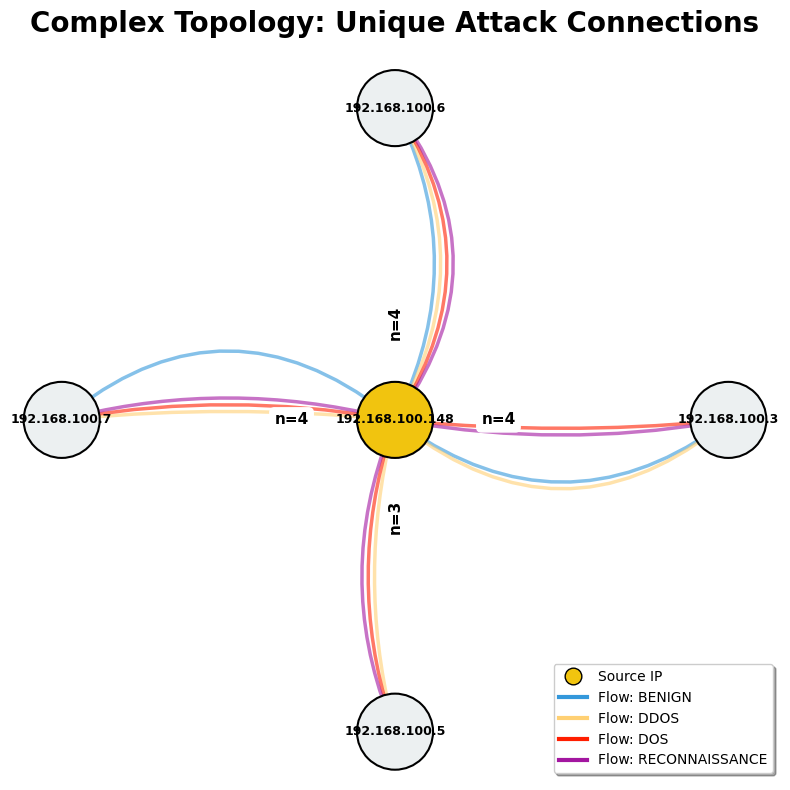

In [48]:
import networkx as nx
import matplotlib.pyplot as plt
import math
from matplotlib.lines import Line2D

def plot_thick_coded_topology(df, src_ip, edges_per_pair=10):
    # 1. Get top destinations
    dst_ips = df[df['source_ip'] == src_ip]['destination_ip'].value_counts().head(4).index.tolist()
    
    G = nx.MultiDiGraph()
    edge_counts = {}
    
    # Define a color palette for specific attack types
    # You can customize these hex codes to match your slide theme
    attack_colors = {
        'benign': '#3498db',         # Blue
        'ddos': "#ffd073",           # Purple
        'dos': "#ff1e00",            # Orange
        'reconnaissance': "#a316a0",  # Yellow/Gold
        'scanning': '#1abc9c',       # Teal
        'infiltration': '#34495e',   # Dark Slate
        'default': '#e74c3c'         # Red (fallback)
    }

    for dst in dst_ips:
        pair_df = df[(df['source_ip'] == src_ip) & (df['destination_ip'] == dst)]
        edge_counts[(src_ip, dst)] = len(pair_df)
        
        # Sample edges
        sample = pair_df.head(edges_per_pair)
        for i, row in sample.iterrows():
            # Store the specific attack type on the edge for color lookup
            G.add_edge(src_ip, dst, key=i, attack=row['attack'].lower())

    # 2. Layout
    plt.figure(figsize=(8, 8))
    pos = {src_ip: (0, 0)}
    for i, dst in enumerate(dst_ips):
        angle = (2 * math.pi / len(dst_ips)) * i
        pos[dst] = (math.cos(angle) * 1.5, math.sin(angle) * 1.5)

    # 3. Draw Thick Arcs with specific colors
    # We track which types we've drawn for the legend
    types_in_graph = set()

    for u, v, k in G.edges(keys=True):
        atk_type = G.edges[u, v, k]['attack']
        types_in_graph.add(atk_type)
        
        # Color lookup
        color = attack_colors.get(atk_type, attack_colors['default'])
        
        # Calculate radius for 'rainbow' stacking
        rad = 0.05 + (k % edges_per_pair) * 0.04
        
        nx.draw_networkx_edges(
            G, pos, 
            edgelist=[(u, v)], 
            connectionstyle=f'arc3, rad={rad}',
            alpha=0.6,          # Increased alpha for better color visibility
            edge_color=color, 
            width=2.5,          # THICKER LINES
            arrowstyle='-|>', 
            arrowsize=12
        )
    
    # 4. Draw Nodes
    # Using a simple logic: if node is source -> yellow, else -> light gray 
    # (since edges are now the primary color focus)
    n_colors = ['#f1c40f' if n == src_ip else '#ecf0f1' for n in G.nodes()]
    
    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color=n_colors, 
                           edgecolors='black', linewidths=1.5)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

    # 5. Add Weighted Labels
    label_G = nx.DiGraph(); label_G.add_edges_from(edge_counts.keys())
    edge_labels = {k: f"n={v:,}" for k, v in edge_counts.items()}
    nx.draw_networkx_edge_labels(label_G, pos, edge_labels=edge_labels, 
                                 font_size=11, font_weight='bold', label_pos=0.3)

    # 6. Comprehensive Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Source IP', 
               markerfacecolor='#f1c40f', markersize=12, markeredgecolor='black')
    ]
    
    # Add a line to the legend for every attack type present in the graph
    for atk in sorted(types_in_graph):
        color = attack_colors.get(atk, attack_colors['default'])
        legend_elements.append(Line2D([0], [0], color=color, lw=3, label=f'Flow: {atk.upper()}'))

    plt.legend(handles=legend_elements, loc='lower right', frameon=True, shadow=True)
    
    plt.title(f"Complex Topology: Unique Attack Connections", 
          fontsize=20, 
          fontweight='bold',
          x=0.5,
          y=1,
          pad=20)          # Adds space between the title and the graph nodes
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_thick_coded_topology(complex_df, '192.168.100.148')